# Synthesis Agent
This agent is responsible for the transformation process. It will use an `transformation.md` file to protocol each step in the process. In this file the agent writes a step-by-step plan for the transformation as well as some thoughts on the transformation process itself. There might be some challenges which can occur.

In [1]:
from pathlib import Path
import sys
import logging

logging.basicConfig(level=logging.INFO)

ROOT = Path.cwd().parent.parent
logging.info(f"Adding {ROOT} to Python path for imports in kernel.")
sys.path.insert(0, str(ROOT))  # ROOT, nicht SRC!

# Load config with changed env path
from src.config import Config
config = Config.get_instance(env_path=ROOT / ".env")


INFO:root:Adding /Users/lukas/Masterarbeit/agents/bxAgent to Python path for imports in kernel.


After the module initialization, the agent should be build and the setup has to be prepared. For that we need a filesystem backend so that the agent can write arbitrary files.

In [2]:
from deepagents.backends import LocalShellBackend

backend = LocalShellBackend(
    root_dir=config.WORKSPACE.PATH / "transformation",
    virtual_mode=True
)

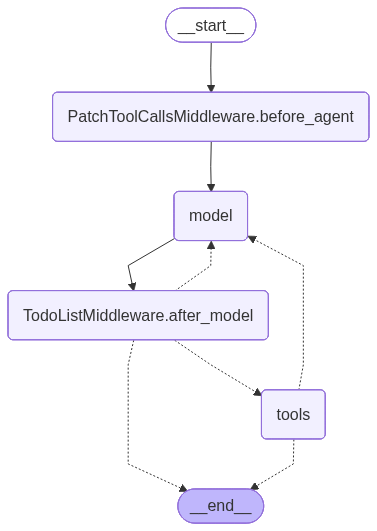

In [3]:

from src.agents.synthesis import build_synthesis_agent

agent = build_synthesis_agent(backend=backend)

config = {
    "configurable": {
        "thread_id": "some_id"
    }
}

agent

Lets test the agent to write a transformation about the Families2Person Problem. Exampleprompt is from "Prompting Bidirectional Model Transformations - The Good, The Bad and The Ugly"

In [4]:

from langchain.messages import HumanMessage

prompt = (
    "The Families model stores Families (characterized by  their name) and corresponding FamilyMembers ( with given first name)."
    "FamilyMembers might take different roles within a Family (father, mother, sons, daughters)."
    "The Persons model on the other hand consists of a flat set of Persons, which are either Male or Female and which are characterized by their names and birthdays."
    "FamilyMembers are transformed to Male persons, if they are attached to a Family via the father or sons reference and to Female persons otherwise." 
    "The person's name attribute is then a concatenation of the FamilyMember name and the Family name."
    "The transformation of persons to FamilyMembers (and Families) works analogously."
    "Could you please also provide code for the opposite  direction?"
    "Please take into account that the transformation from the persons model to the families model should be configurable: "
    "    One configuration parameter should indicate if persons should be added to already existing families with matching name." 
    "    And the other configuration parameter indicates the role in which a person should be added."
    "    Prefer parent means, that if the father or mother role is not already taken in the family, the transformed person should be added as father or mother."
    "Assume that the model classes are already generated and available for import. You can use them in your transformation code."
    "The model classes are generated by the Eclipse Modeling Framework (EMF) and follow the standard EMF code generation patterns."
)

for chunk in agent.stream(
    input={
        "messages": [HumanMessage(content=prompt)]
    },
    config=config,
    version="v2"
):
    logging.info(chunk)

INFO:root:{'type': 'updates', 'ns': (), 'data': {'PatchToolCallsMiddleware.before_agent': {'messages': Overwrite(value=[HumanMessage(content="The Families model stores Families (characterized by  their name) and corresponding FamilyMembers ( with given first name).FamilyMembers might take different roles within a Family (father, mother, sons, daughters).The Persons model on the other hand consists of a flat set of Persons, which are either Male or Female and which are characterized by their names and birthdays.FamilyMembers are transformed to Male persons, if they are attached to a Family via the father or sons reference and to Female persons otherwise.The person's name attribute is then a concatenation of the FamilyMember name and the Family name.The transformation of persons to FamilyMembers (and Families) works analogously.Could you please also provide code for the opposite  direction?Please take into account that the transformation from the persons model to the families model shoul